# Neural network classification


In [106]:
import torch
import numpy as np
from torch import nn
from sklearn.datasets import make_circles

In [67]:
# Make 1000 samples

# Create circles

X , y = make_circles(1000,
                     noise=0.03,
                     random_state=42)

len(X), len(y)

X[:5], y[:5]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

In [68]:
# Make Dataframe of circle data

import pandas as pd
circles = pd.DataFrame({'X1': X[:,0],
                       'X2': X[:,1],
                       "lable":y})

circles.head()



,X1,X2,lable
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


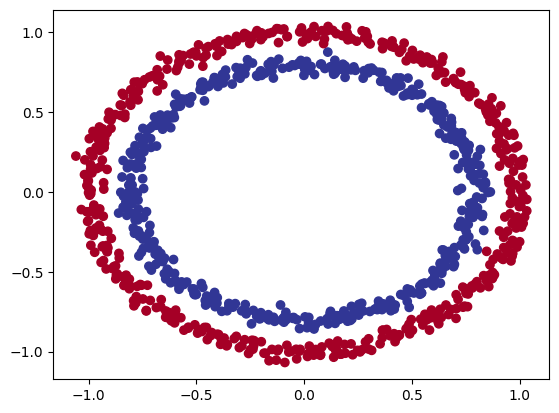

In [69]:
# Visualize

import matplotlib.pyplot as plt

plt.scatter(x=X[:,0],
            y=X[:,1],
            c=y,
            cmap=plt.cm.RdYlBu )

Note: The data we're working with is often refered to as a toy dataset.

## 1. Check input and output shapes

In [70]:
X.shape , y.shape

((1000, 2), (1000,))

### 1.2 Turning data into tensors and create train and test split

In [71]:
# Turn data into tensors

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [72]:
torch.manual_seed(42)

In [73]:
#Split data into training and test set
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,
                                                 test_size=0.2,
                                                 random_state=42)

## Building model

let's build a model to classify

To do so, we want to:
1. Setup device agnostic code so our code will run on an accelerator(GPU) if available
2. Construct model (by subclassing nn.module)
3. Define a loss function and optimizer
4. Create a training and test loop

In [74]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

Now we've setup device agnostic code, lets create a model that:
1. Subclass "nn.module" (almst all models in pytorch subclass "nn.module")
2. Create 2 "nn.linear()" layers that are capable of handling the shapes of out data
3. Defines a "forward()" method that outlines the forward pass of the module
4. Instantiate an instance of out model class and send it to the target device

In [75]:
# 1. Construct a model that subclasses nn.Module

class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()

    # 2. Create 2 nn.Linear layers capable of handeling the shapes of out data
    self.layer1 = nn.Linear(in_features=2,out_features=5) #takes 2 features in and 5 features out
    self.layer2 = nn.Linear(in_features=5,out_features=1) # takes 5 features in and 1 out

  # 3. Define a forward() method that outline forward pass
  def forward(self,x):
    return self.layer2(self.layer1(x)) # x->layer1->layer2->output


In [76]:
# 4. Instantiate an instance of our model class and send it to the target device
model_0 = CircleModelV1().to(device)

model_0

CircleModelV1(
  (layer1): Linear(in_features=2, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=1, bias=True)
)

In [77]:
# Let's replicate the model above using nn.Sequential()

model_0 = nn.Sequential(
    nn.Linear(in_features=2,out_features=5),
    nn.Linear(in_features=5,out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [78]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]], device='cuda:0')),
             ('0.bias',
              tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370], device='cuda:0')),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]], device='cuda:0')),
             ('1.bias', tensor([-0.1213], device='cuda:0'))])

In [79]:
# Make prediction
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))

print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test sample: {len(X_test)}, Shape: {X_test.shape}")
print(f"\n First 10 predictions: \n {untrained_preds[:10]}")
print(f"\nFrist 10 labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test sample: 200, Shape: torch.Size([200, 2])

 First 10 predictions: 
 tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967],
        [ 0.2968],
        [ 0.1405],
        [ 0.2178],
        [ 0.0805],
        [-0.0284]], device='cuda:0')

Frist 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


### 2.1 Setup loss function and optimizer

1. Which loss function or optimizer should you use?

Again.. this is problem specific

For example for regression you might want MAE or MSE

For classification you might want binary cross entropy or categorical cross entropy

As a reminder, the loss function measures how wrong your model prediction are

And for optimizers, two of the most common and userful are SDG and Adam

* For the loss function we're going to user `torch.nn.BCEWithLogitsLoss()`

In [80]:
# Setup the loss function
# nn.BCELoss() = requires inputs to have gone through the sigmoid activation function prior to input to BCELOSS
loss_fn = nn.BCEWithLogitsLoss() #BCEWithLogitsLoss  = sigmoid activation function

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)


In [81]:
# Calculate accuracy - out of 100 examples, what percentage does out model get right?

def accuracy_fn(y_true,y_pred):
  correct = torch.eq(y_true,y_pred).sum().item()
  acc = (correct/len(y_pred)) * 100
  return acc

## 3. Training model

To train our model, we're going to build a traning loop:
1. Forward pass
2. Calculate the loss
3. Optimizer Zero grad
4. Loss backward(backpropagation)
5. Optimizer Step ( gradient descent)

### 3.1 Going from raw logits -> prediction probabilities -> prediction labels

Out model outputs are going to be raw logits

We can convert these **logits** into prediction probabilities by passing them to some kind of activation functuon (e.g. sigmoid for binary cross entorpy and softmax for multiclass classification)

Then we can convert out model's prediction probabilities to **prediction lables** by either rounding them or taking the `argmax()`

In [82]:
# View the first 5 outputs of the forward pass on the test data

y_logits = model_0(X_test.to(device))[:5]

y_logits

tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967]], device='cuda:0', grad_fn=<SliceBackward0>)

In [87]:
torch.manual_seed(42)

#Set the number of epochs
epochs = 1000

#Put data to target device
X_train,y_train = X_train.to(device),y_train.to(device)
X_test,y_test= X_test.to(device),y_test.to(device)


# Training loop
for epoch in range(epochs):

  # Training
  model_0.train()

  # 1. Forward pass
  y_logits = model_0(X_train).squeeze().to(device)
  y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> pred probs -> pred labels

  # 2. Calculate loss/accuracy
  loss = loss_fn(y_logits, # nn.BCEWithLogitsLoss expects raw logits as input
                   y_train)

  accuracy = accuracy_fn(y_true = y_train,
                         y_pred = y_pred)

  # 3. Optimizer zero gra
  optimizer.zero_grad()

  #4. Loss backward
  loss.backward()

  # 5. Optimizer step (gradient descent)
  optimizer.step()


  # Testing
  model_0.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logit = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logit))

    # 2. Calculate test loss/acc
    test_loss = loss_fn(test_logit,
                        y_test)

    test_acc = accuracy_fn(y_true=y_test,
                          y_pred=test_pred)

  # Print out what's happnin
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {accuracy:.2f}%  | Test Loss : {test_loss:.5f} , Accuracy: {test_acc:.2f}%")







Epoch: 0 | Loss: 0.69310, Acc: 51.12%  | Test Loss : 0.69337 , Accuracy: 48.50%
Epoch: 100 | Loss: 0.69304, Acc: 50.75%  | Test Loss : 0.69377 , Accuracy: 46.50%
Epoch: 200 | Loss: 0.69301, Acc: 51.38%  | Test Loss : 0.69404 , Accuracy: 47.50%
Epoch: 300 | Loss: 0.69299, Acc: 50.88%  | Test Loss : 0.69423 , Accuracy: 47.00%
Epoch: 400 | Loss: 0.69299, Acc: 51.25%  | Test Loss : 0.69437 , Accuracy: 46.50%
Epoch: 500 | Loss: 0.69298, Acc: 51.25%  | Test Loss : 0.69446 , Accuracy: 46.00%
Epoch: 600 | Loss: 0.69298, Acc: 51.50%  | Test Loss : 0.69453 , Accuracy: 45.50%
Epoch: 700 | Loss: 0.69298, Acc: 51.38%  | Test Loss : 0.69458 , Accuracy: 45.00%
Epoch: 800 | Loss: 0.69298, Acc: 51.38%  | Test Loss : 0.69461 , Accuracy: 45.00%
Epoch: 900 | Loss: 0.69298, Acc: 51.38%  | Test Loss : 0.69463 , Accuracy: 45.00%


## 4. Make prediction and evaluate the model

From the metrics it looks like out model isn't learning anything...

So to inspect it let's make some predictions and make them visual!

In other words, "Visualize, visualize, visualize!"

To do so, we're going to import a function called `plot_decision_boundary()`

In [107]:
def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())


# Plot linear data or training and test and predictions (optional)
def plot_predictions(
    train_data, train_labels, test_data, test_labels, predictions=None
):
    """
  Plots linear training data and test data and compares predictions.
  """
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        # Plot the predictions in red (predictions were made on the test data)
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14})



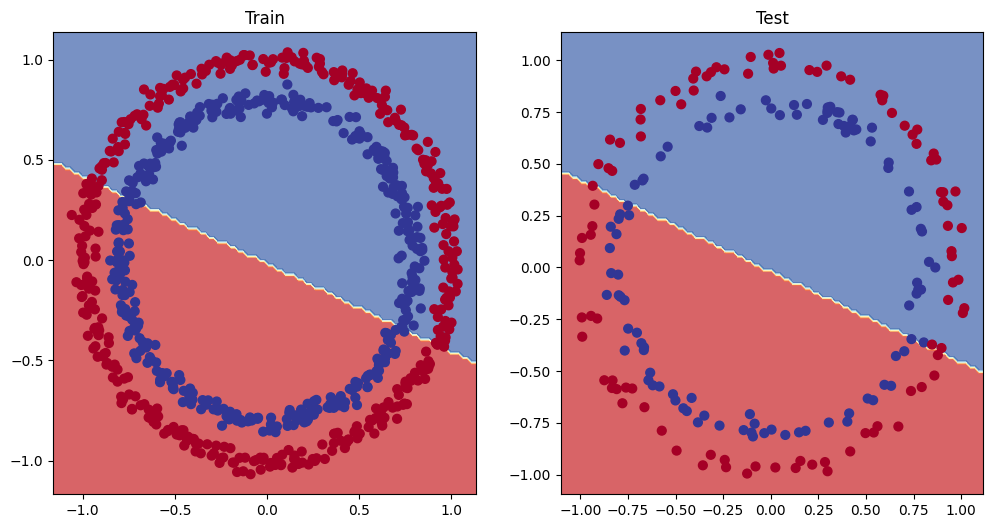

In [109]:
# Plot decision boundary of the model

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0,X_test,y_test)
#

## 5. Improving a model ( from a model prespective)

* Add more layers - give the model more chances to learn about patterns in the data
* add more hidden units - go from 5 hidden units to 10 hidden  
* Fit for longer
* Changing the activation functions
* Change the learning rate
* Change the loss function


In [116]:
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer_1 = nn.Linear(in_features=2 , out_features=10)
    self.layer_2 = nn.Linear(in_features=10 , out_features=10)
    self.layer_3 = nn.Linear(in_features=10 , out_features=1)
    self.relu = nn.ReLU()

  def forward(self,x):
    #Where should we put our non linear-activation function

    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))



In [118]:
model_2 = CircleModelV2().to(device)
model_2

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [121]:
# Setup loss and optimizer

loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.1)

In [126]:
torch.manual_seed(42)

# training loop

epochs = 2000

X_train,y_train = X_train.to(device),y_train.to(device)
X_test,y_test = X_test.to(device),y_test.to(device)
for epoch in range(epochs):

  #Train

  model_2.train()
  train_logits = model_2(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(train_logits))

  train_loss = loss_function(train_logits,
                       y_train)

  train_acc = accuracy_fn(y_true=y_train,
                          y_pred=y_pred)

  optimizer.zero_grad()

  train_loss.backward()

  optimizer.step()

  #Test
  model_2.eval()
  with torch.inference_mode():
    test_logits = model_2(X_test).squeeze()
    y_pred = torch.round(torch.sigmoid(test_logits))

    test_loss=loss_function(test_logits,
                       y_test)

    test_acc = accuracy_fn(y_true=y_test,
                          y_pred=y_pred)

  if epoch % 100 == 0:
    print(f"The train Loss: {train_loss:.5f} | Accuracy: {train_acc:.2f}% and test loss: {test_loss:.5f} | Accuaracy: {test_acc:.2f}%")


The train Loss: 0.00132 | Accuracy: 100.00% and test loss: 0.01468 | Accuaracy: 99.50%
The train Loss: 0.00131 | Accuracy: 100.00% and test loss: 0.01464 | Accuaracy: 99.50%
The train Loss: 0.00129 | Accuracy: 100.00% and test loss: 0.01459 | Accuaracy: 99.50%
The train Loss: 0.00128 | Accuracy: 100.00% and test loss: 0.01454 | Accuaracy: 99.50%
The train Loss: 0.00126 | Accuracy: 100.00% and test loss: 0.01450 | Accuaracy: 99.50%
The train Loss: 0.00125 | Accuracy: 100.00% and test loss: 0.01446 | Accuaracy: 99.50%
The train Loss: 0.00123 | Accuracy: 100.00% and test loss: 0.01441 | Accuaracy: 99.50%
The train Loss: 0.00122 | Accuracy: 100.00% and test loss: 0.01437 | Accuaracy: 99.50%
The train Loss: 0.00120 | Accuracy: 100.00% and test loss: 0.01433 | Accuaracy: 99.50%
The train Loss: 0.00119 | Accuracy: 100.00% and test loss: 0.01429 | Accuaracy: 99.50%
The train Loss: 0.00118 | Accuracy: 100.00% and test loss: 0.01425 | Accuaracy: 99.50%
The train Loss: 0.00116 | Accuracy: 100.00%

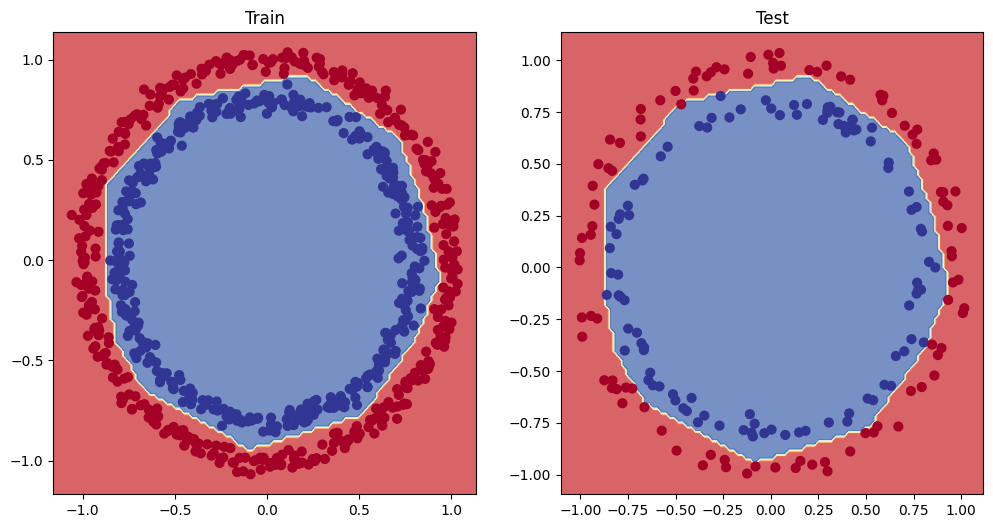

In [128]:
# Plot decision boundary of the model

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_2,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_2,X_test,y_test)
#